<a href="https://colab.research.google.com/github/mkg6573/Social_media_impact_on_life_ML_/blob/main/Analysis/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# Load the dataset
df = pd.read_csv('/content/Social_media_impact_on_life.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [7]:
df.shape

(1705, 11)

In [8]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')

Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


Check Missing Values

In [11]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


Statistical Summary

In [14]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


For categorical columns:

In [15]:
df.describe(include='object')

,Gender,Academic_Level,Country,Most_Used_Platform,Affects_Academic_Performance,Overall_Impact
count,1705,1705,1705,1705,1705,1705
unique,2,3,111,12,2,3
top,Male,Undergraduate,Other,Instagram,Yes,Negative
freq,878,721,667,389,1011,939


Check Duplicate Rows

In [17]:
print(df.duplicated().sum())

0


 Check Target Column Distribution

In [18]:
df['Overall_Impact'].value_counts()

,count
Overall_Impact,
Negative,939
Positive,499
Neutral,267


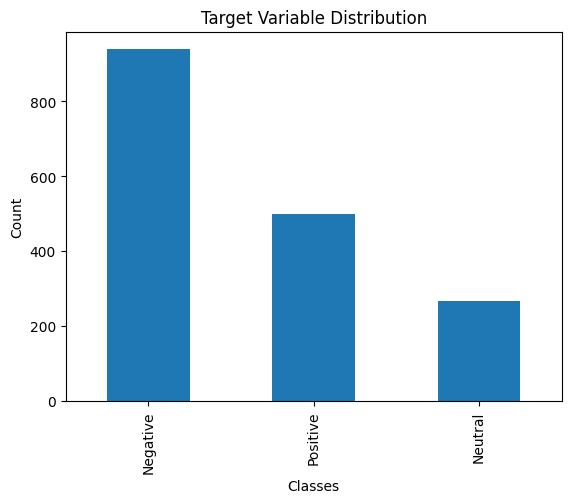

In [19]:
df['Overall_Impact'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

Separate Numerical and Categorical Columns

In [22]:
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')


In [23]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Overall_Impact'],
      dtype='object')


In [24]:
corr = df.corr(numeric_only=True)
print(corr)

                       Student_ID       Age  Avg_Daily_Usage_Hours  \
Student_ID               1.000000  0.070681               0.063552   
Age                      0.070681  1.000000              -0.053610   
Avg_Daily_Usage_Hours    0.063552 -0.053610               1.000000   
Sleep_Hours_Per_Night    0.003809  0.063745              -0.817444   
Mental_Health_Score     -0.018457  0.083701              -0.826391   

                       Sleep_Hours_Per_Night  Mental_Health_Score  
Student_ID                          0.003809            -0.018457  
Age                                 0.063745             0.083701  
Avg_Daily_Usage_Hours              -0.817444            -0.826391  
Sleep_Hours_Per_Night               1.000000             0.785372  
Mental_Health_Score                 0.785372             1.000000  


Heat map

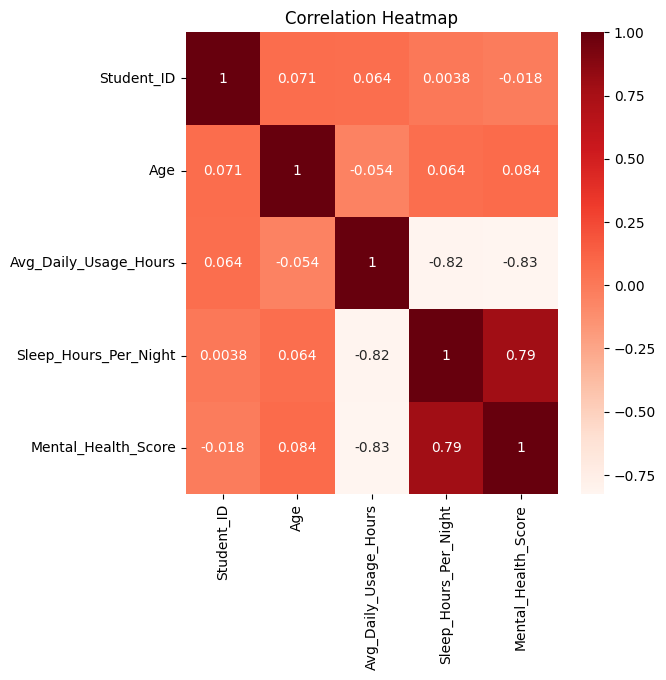

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

sns.heatmap(corr,annot=True,cmap='Reds')

plt.title("Correlation Heatmap")

plt.show()

Check Unique Values

In [36]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("----------------")

Gender
['Male' 'Female']
----------------
Academic_Level
['Undergraduate' 'Graduate' 'High School']
----------------
Country
['Other' 'Canada' 'USA' 'India' 'Australia' 'UK' 'Germany' 'Bangladesh'
 'Brazil' 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia'
 'China' 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'Armenia'
 'Georgia' 'Azerbaijan' 'Cyprus

Outlier Detection

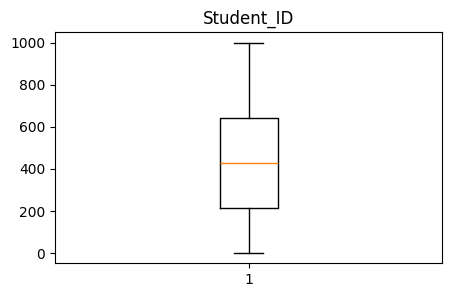

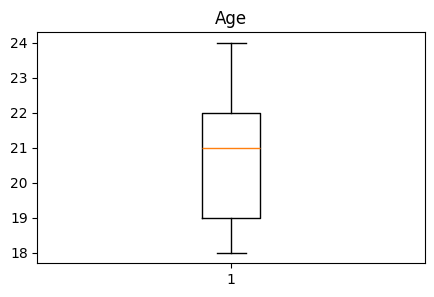

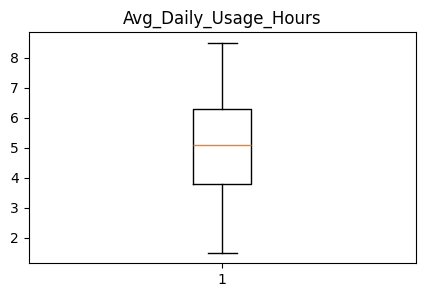

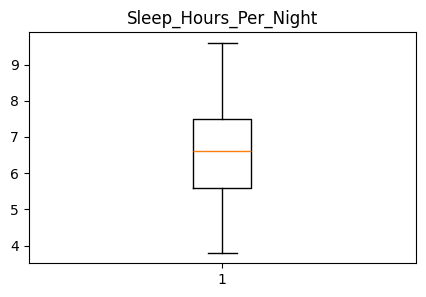

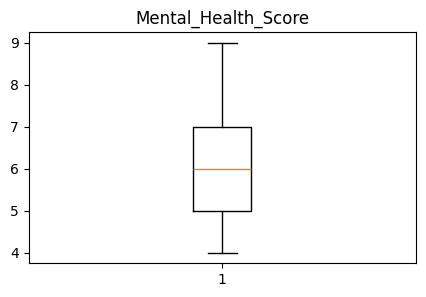

In [38]:
for col in num_cols:

    plt.figure(figsize=(5,3))

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

Class Balance Check

In [39]:
df['Overall_Impact'].value_counts(normalize=True)*100

,proportion
Overall_Impact,
Negative,55.073314
Positive,29.266862
Neutral,15.659824


Draw bar graph for each categorical column

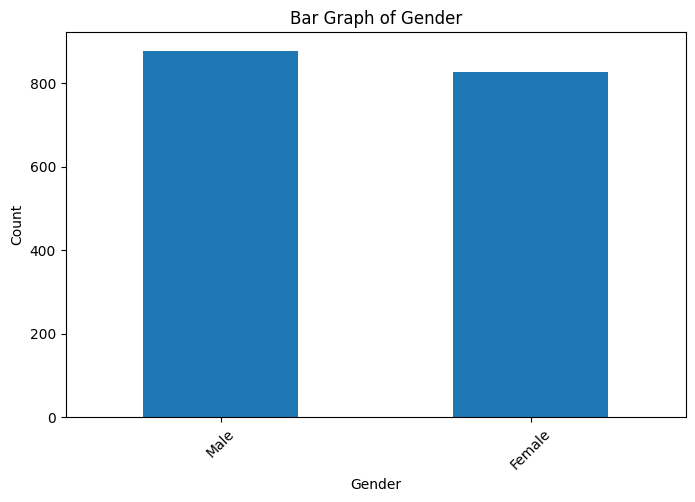

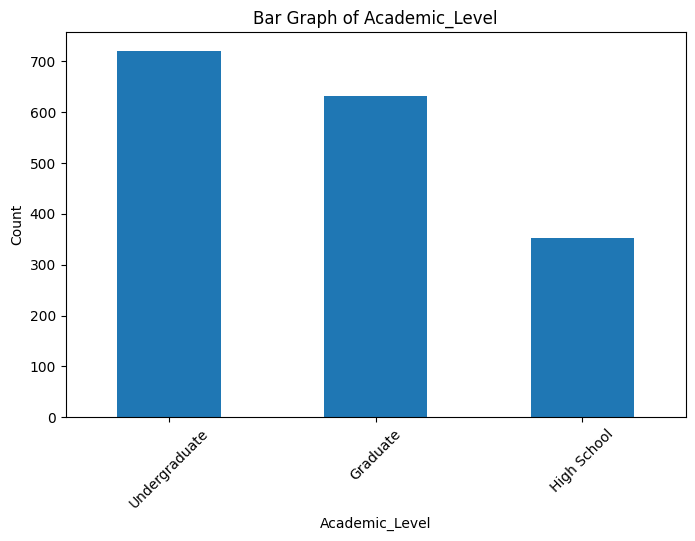

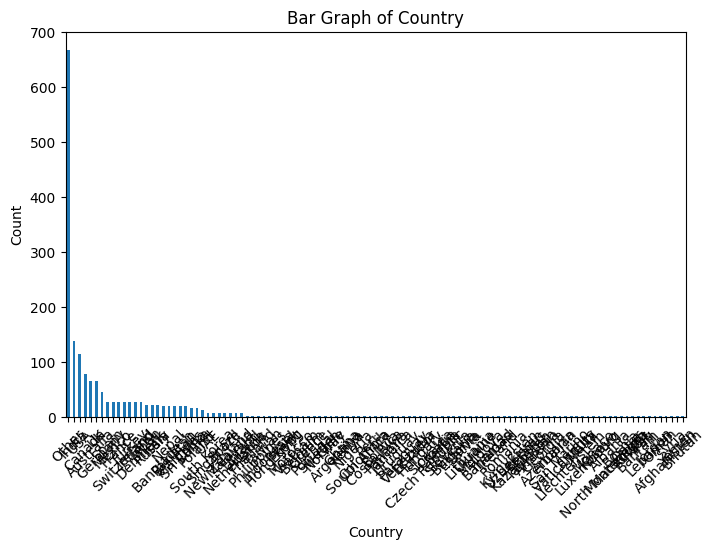

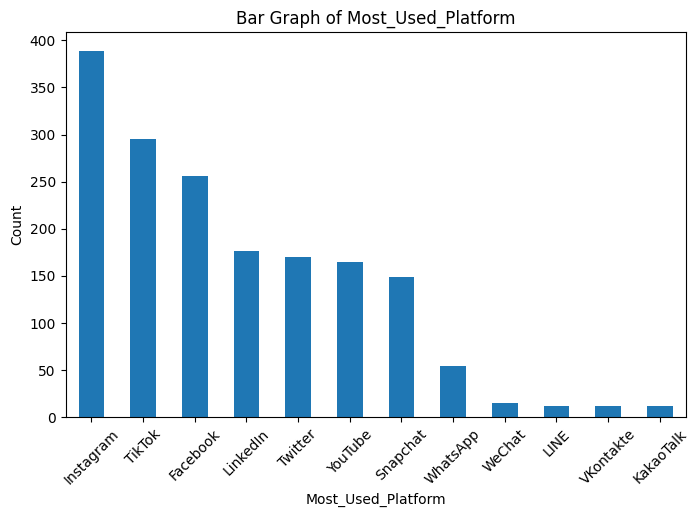

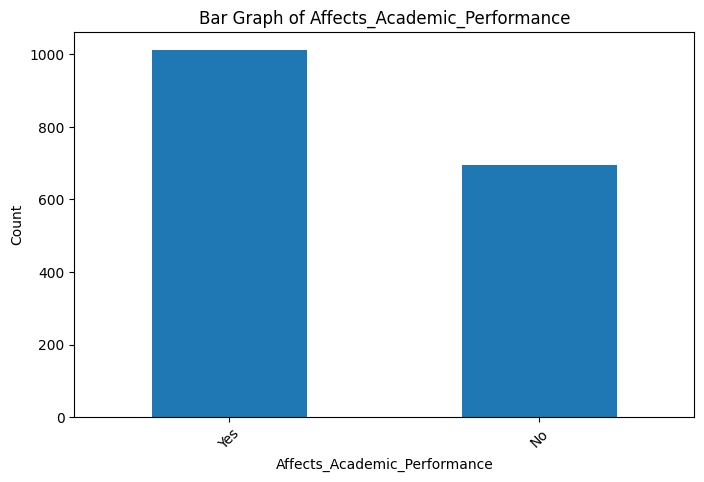

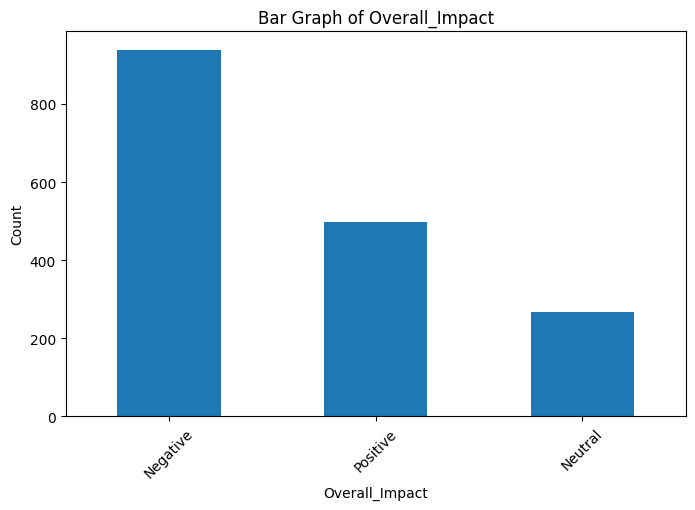

In [40]:

for col in cat_cols:

    plt.figure(figsize=(8,5))

    df[col].value_counts().plot(kind='bar')

    plt.title(f"Bar Graph of {col}")

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()

Student_ID  Delete

Reason:

1. It is only a unique identifier.

2. It has no relationship with Overall_Impact.
3. Models may learn useless patterns from IDs.



Delete Country


1. Too many unique countries
2. Country is not important
3. Avoid unnecessary complexity

In [41]:
df = df.drop('Student_ID', axis=1)

In [42]:
df = df.drop('Country', axis=1)

In [43]:
df.to_csv("Social_media_impact_on_life_Clean_Dataset.csv", index=False)